<a href="https://colab.research.google.com/github/aryansharma-d/AI-ML-JOURNEY/blob/main/readmission_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import kagglehub

path = kagglehub.dataset_download("abhaypanchal/hospital-readmission-prediction-dataset")
print(path)

Using Colab cache for faster access to the 'hospital-readmission-prediction-dataset' dataset.
/kaggle/input/hospital-readmission-prediction-dataset


In [19]:
import os
import pandas as pd

files = os.listdir(path)
print(files)

df = pd.read_csv(f"{path}/{files[0]}")
df.head()

['hospital_readmission.csv']


,age,length_of_stay_days,num_diagnoses,num_medications,prev_admissions,glucose_level,bmi,has_diabetes,discharge_type,readmitted_30days
0,22.0,28.0,2.0,13.0,4.0,89.1,48.4,1.0,2.0,0
1,44.0,12.0,7.0,11.0,2.0,254.8,23.9,1.0,0.0,1
2,34.0,15.0,9.0,16.0,6.0,270.2,16.7,0.0,1.0,1
3,39.0,15.0,5.0,16.0,6.0,208.6,18.2,0.0,1.0,1
4,62.0,24.0,1.0,6.0,6.0,233.1,44.0,0.0,0.0,1


In [20]:
df.info()
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  31653 non-null  object 
 1   length_of_stay_days  31652 non-null  float64
 2   num_diagnoses        31655 non-null  float64
 3   num_medications      31654 non-null  float64
 4   prev_admissions      31654 non-null  float64
 5   glucose_level        31654 non-null  float64
 6   bmi                  31654 non-null  float64
 7   has_diabetes         31653 non-null  float64
 8   discharge_type       31655 non-null  float64
 9   readmitted_30days    32300 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 2.5+ MB


['age',
 'length_of_stay_days',
 'num_diagnoses',
 'num_medications',
 'prev_admissions',
 'glucose_level',
 'bmi',
 'has_diabetes',
 'discharge_type',
 'readmitted_30days']

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split


df['age'] = df['age'].fillna(df['age'].mode()[0])

numeric_cols = ['length_of_stay_days', 'num_diagnoses', 'num_medications',
                 'prev_admissions', 'glucose_level', 'bmi',
                 'has_diabetes', 'discharge_type']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

from sklearn.preprocessing import LabelEncoder
if df['age'].dtype == 'object':
    df['age'] = LabelEncoder().fit_transform(df['age'])

X = df.drop(columns=['readmitted_30days'])
y = df['readmitted_30days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Target distribution:\n", y.value_counts(normalize=True))


Train shape: (25840, 9)
Test shape: (6460, 9)
Target distribution:
 readmitted_30days
0    0.500341
1    0.499659
Name: proportion, dtype: float64


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, precision_recall_curve

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(penalty="l2", solver="liblinear",
                                class_weight="balanced", max_iter=1000))
])

param_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)

y_prob = gs.predict_proba(X_test)[:, 1]
print("Best C:", gs.best_params_)
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Best C: {'clf__C': 0.01}
ROC-AUC: 0.8757362289435264


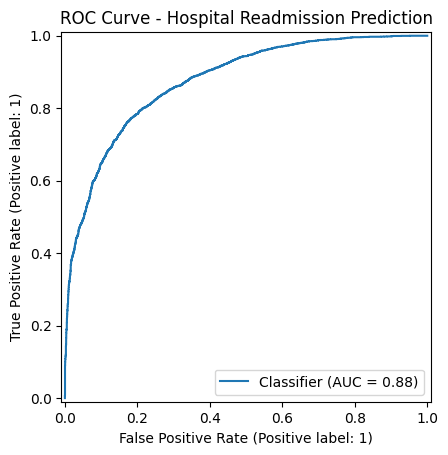

              precision    recall  f1-score   support

           0       0.79      0.80      0.79      3232
           1       0.80      0.79      0.79      3228

    accuracy                           0.79      6460
   macro avg       0.79      0.79      0.79      6460
weighted avg       0.79      0.79      0.79      6460

Confusion Matrix:
[[2577  655]
 [ 685 2543]]


In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, classification_report, confusion_matrix

# ROC curve plot
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.savefig("roc_readmission.png")
plt.show()

# classification report at default 0.5 threshold
y_pred = gs.predict(X_test)
print(classification_report(y_test, y_pred))

# confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [26]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)


threshold = 0.35
y_pred_lower = (y_prob >= threshold).astype(int)

print(f"--- Threshold = {threshold} ---")
print(classification_report(y_test, y_pred_lower))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lower))

--- Threshold = 0.35 ---
              precision    recall  f1-score   support

           0       0.85      0.65      0.73      3232
           1       0.71      0.89      0.79      3228

    accuracy                           0.77      6460
   macro avg       0.78      0.77      0.76      6460
weighted avg       0.78      0.77      0.76      6460

Confusion Matrix:
[[2088 1144]
 [ 368 2860]]
